In [1]:
import numpy as np
import json
from matplotlib import pyplot as plt
import matplotlib
import math
from scipy.stats import linregress
from scipy.optimize import curve_fit

# # Load in data from JSON
with open(r'C:\Users\Riley\Desktop\Code\FlowSim\Results\2025-6-6-11-34-3_Re400.0_dx0.005_dt0.0025_t1.json','r') as file:
    space_ref = json.load(file)

with open(r'C:\Users\Riley\Desktop\Code\FlowSim\Results\2025-6-6-11-35-59_Re400.0_dx0.01_dt0.0025_t1.json','r') as file:
    space1 = json.load(file)

with open(r'C:\Users\Riley\Desktop\Code\FlowSim\Results\2025-6-6-11-37-1_Re400.0_dx0.02_dt0.0025_t1.json','r') as file:
    space2 = json.load(file)

with open(r'C:\Users\Riley\Desktop\Code\FlowSim\Results\2025-6-6-11-37-55_Re400.0_dx0.025_dt0.0025_t1.json','r') as file:
    space3 = json.load(file)

with open(r'C:\Users\Riley\Desktop\Code\FlowSim\Results\2025-6-6-11-39-37_Re400.0_dx0.04_dt0.0025_t1.json','r') as file:
    space4 = json.load(file)


In [2]:
### Plot the spatial convergence Error

u_ref = space_ref['u_vel']
v_ref = space_ref['v_vel']
nx_ref = space_ref['nx']
dx_ref = space_ref['dx']

u_1 = space1['u_vel']
v_1 = space1['v_vel']
nx_1 = space1['nx']
dx_1 = space1['dx']

u_2 = space2['u_vel']
v_2 = space2['v_vel']
nx_2 = space2['nx']
dx_2 = space2['dx']

u_3 = space3['u_vel']
v_3 = space3['v_vel']
nx_3 = space3['nx']
dx_3 = space3['dx']

u_4 = space4['u_vel']
v_4 = space4['v_vel']
nx_4 = space4['nx']
dx_4 = space4['dx']

In [3]:
def compute_spatial_error(u_ref, v_ref, u_1, v_1, nx_ref, nx_1):
    
    u_ref = np.array(u_ref)
    v_ref = np.array(v_ref)
    u_1 = np.array(u_1)
    v_1 = np.array(v_1)


    total_error = []
    ratio = nx_ref / nx_1
    #print(ratio)
    ratio = int(ratio)
    
    for i in range(len(u_1)):
        for j in range(len(u_1)):
            total_error.append(abs(u_ref[i*ratio, j*ratio]- u_1[i,j]))
            total_error.append(abs(v_ref[i*ratio, j*ratio]- v_1[i,j]))

    per_point_error = np.sum(total_error)/(nx_1**2)

    return per_point_error

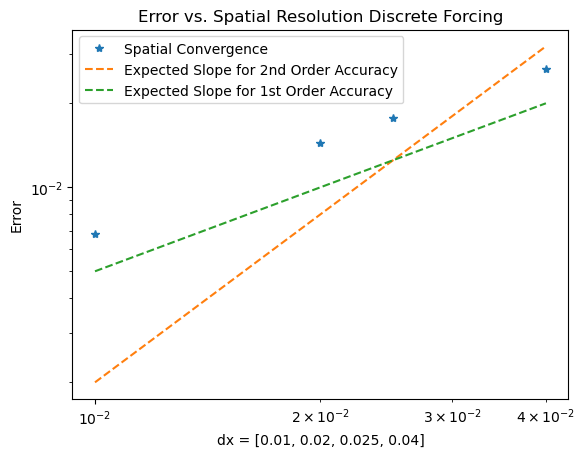

In [ ]:
# Plot Spatial Errors vs. dx
error_1 = compute_spatial_error(u_ref, v_ref, u_1, v_1, nx_ref, nx_1)
error_2 = compute_spatial_error(u_ref, v_ref, u_2, v_2, nx_ref, nx_2)
error_3 = compute_spatial_error(u_ref, v_ref, u_3, v_3, nx_ref, nx_3)
error_4 = compute_spatial_error(u_ref, v_ref, u_4, v_4, nx_ref, nx_4)

dxs = [dx_1, dx_2, dx_3, dx_4]
errors = [error_1, error_2, error_3, error_4]

expected_dx = [i**2*2e1 for i in dxs]
expected_e1 = [i**1*7e-1 for i in dxs]

plt.figure()
plt.loglog(dxs, errors, '*')
plt.loglog(dxs, expected_dx, '--')
plt.loglog(dxs, expected_e1, '--')
plt.title('Error vs. Spatial Resolution Discrete Forcing')
plt.legend(['Spatial Convergence', 'Expected Slope for 2nd Order Accuracy','Expected Slope for 1st Order Accuracy'])
plt.xlabel(f'dx = {dxs}')
plt.ylabel('Error')
plt.show()

In [5]:
time_data = []

with open(r'C:\Users\Riley\Desktop\Code\FlowSim\Results\2025-6-4-20-55-20_Re400.0_dx0.0125_dt0.0001_t1.json','r') as file:
    time_data.append(json.load(file))

with open(r'C:\Users\Riley\Desktop\Code\FlowSim\Results\2025-6-4-20-37-1_Re400.0_dx0.0125_dt0.0002_t1.json','r') as file:
    time_data.append(json.load(file))

with open(r'C:\Users\Riley\Desktop\Code\FlowSim\Results\2025-6-4-20-38-22_Re400.0_dx0.0125_dt0.0005_t1.json','r') as file:
    time_data.append(json.load(file))

with open(r'C:\Users\Riley\Desktop\Code\FlowSim\Results\2025-6-4-20-39-8_Re400.0_dx0.0125_dt0.001_t1.json','r') as file:
    time_data.append(json.load(file))

with open(r'C:\Users\Riley\Desktop\Code\FlowSim\Results\2025-6-4-20-39-40_Re400.0_dx0.0125_dt0.002_t1.json','r') as file:
    time_data.append(json.load(file))

with open(r'C:\Users\Riley\Desktop\Code\FlowSim\Results\2025-6-4-20-40-9_Re400.0_dx0.0125_dt0.005_t1.json','r') as file:
    time_data.append(json.load(file))


In [6]:
def compute_time_error(time_data):
    
    per_point_error = []
    #print(time_data[0])
    u_ref = np.array(time_data[0]['u_vel'])
    v_ref = np.array(time_data[0]['v_vel'])
    nx = time_data[0]['nx']

    for sim in time_data:

        u_1 = np.array(sim['u_vel'])
        v_1 = np.array(sim['v_vel'])

        sim_error = []

        for i in range(len(u_ref)):
            for j in range(len(v_ref)):
                sim_error.append(abs(u_ref[i, j]- u_1[i,j]))
                sim_error.append(abs(v_ref[i, j]- v_1[i,j]))

        per_point_error.append(np.sum(sim_error)/(nx**2))

    return per_point_error

In [7]:
def fit_curve(x, a, b):
    return b*np.power(x, a)

[0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.005]


C:\Users\Riley\AppData\Local\Temp\ipykernel_336820\2837431552.py:12: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(fit_curve, dts[1:3], dt_errors[1:3])


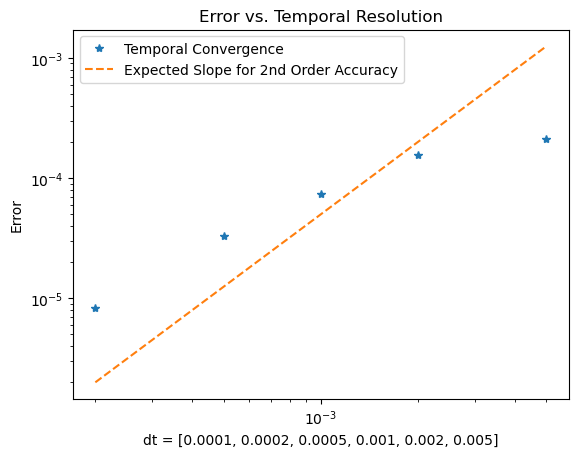

In [8]:
dt_errors = compute_time_error(time_data)
dts = [sim['dt'] for sim in time_data]

#print(dt_errors)
print(dts)

regression = linregress(dt_errors[1:], dts[1:])
#print(regression)

expected = [i**2*5e1 for i in dts[1:]]

popt, pcov = curve_fit(fit_curve, dts[1:3], dt_errors[1:3])
#print(popt)
#dt_smooth = np.logspace(-3.75, -2, 20)

plt.figure()
plt.loglog(dts[1:], dt_errors[1:],'*')
plt.loglog(dts[1:], expected,'--')
#plt.loglog(dt_smooth, fit_curve(dt_smooth, *popt))
plt.legend(['Temporal Convergence', 'Expected Slope for 2nd Order Accuracy'])
plt.xlabel(f'dt = {dts}')
plt.title('Error vs. Temporal Resolution')
plt.ylabel('Error')
plt.show()